In [ ]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


projectPath = Path.cwd().parents[1]
print(projectPath)

In [ ]:
datapath = projectPath / "data" / "z_norm"
df = pd.read_parquet(projectPath / "data" / "ivdata.parquet")

In [ ]:
def plotClusters(labels, sliceMatrix, title, medoids):
    x = np.arange(sliceMatrix.shape[1])

    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, cluster in zip(axes, clusters):
        cluster_data = sliceMatrix[labels == cluster]
        if len(cluster_data) == 0:
            ax.set_title(f"Cluster {cluster} (empty)")
            continue
        
        mean = np.nanmean(cluster_data, axis=0)
        std = np.nanstd(cluster_data, axis=0)

        # if show_individual:
        #     for curve in cluster_data:
        #         ax.plot(x, curve, alpha=0.1)

        ax.fill_between(x, mean - std, mean + std, alpha=0.3, label="±1 std")
        # ax.plot(x,mean, linewidth=2, label="Mean")
        ax.plot(x, sliceMatrix[medoids[cluster]], linewidth=2, label="medoid")
        ax.set_title(f"Cluster {cluster}\nN={len(cluster_data)}")
        ax.grid(alpha=0.3)

        if cluster == clusters[0]:
            ax.legend()

    # Remove unused axes
    for ax in axes[len(clusters):]:
        fig.delaxes(ax)

    fig.supxlabel("Profile coordinate")
    fig.supylabel("Value")

    fig.suptitle(f'Cluster Group: {title}')

    plt.tight_layout()
    # plt.savefig(projectPath / "images/TETS.png")
    plt.show()

In [ ]:
def triIndex(i: int, j: int, n: int) -> int:
    return n * i - i * (i + 1) // 2 + (j - i - 1)

def plotDistanceDistribution(labels, distances):
    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        # sharex=True,
        # sharey=True
    )

    axes = np.atleast_1d(axes).flatten()
    for ax, cluster in zip(axes, clusters):
        idxs, = np.where(labels==cluster)
        if len(idxs) < 10:
            continue
        pairs = np.array(list(combinations(idxs, 2)))
        triIdxs = triIndex(pairs[:, 0], pairs[:, 1], len(labels))

        y = distances[triIdxs]
        y = y[y < 80]
        ax.hist(y, bins=min(len(idxs), 100))
    
    for ax in axes[len(clusters):]:
        fig.delaxes(ax)

    fig.supxlabel("Distances")

    plt.tight_layout()
    plt.show()

In [ ]:
for groupID, (groupLabel, group) in enumerate(df.groupby("Group")):
    keys = np.load(datapath / f"group_{groupID}_keys.npy", allow_pickle=True)
    labels = np.load(datapath / f"group_{groupID}_hdbscan_labels.npy")
    medoids = np.load(datapath / f"group_{groupID}_kmedoid_medoids.npy")
    sliceMatrix = np.load(datapath / f"group_{groupID}_slices.npy")
    
    # n = len(keys)
    # m = n * (n - 1) // 2
    # distances = np.memmap(
    #     datapath / f"group_{groupID}_distances.npy",
    #     mode="r",
    #     dtype=np.float16,
    #     shape=(m,)
    # )
    # distances = np.asarray(distances, dtype=np.float64)
    # plotDistanceDistribution(labels, distances)    

    plotClusters(labels, sliceMatrix, groupLabel, medoids)
    # break


In [ ]:
def chooseRandom(arr, n):
    result = []

    while len(result) < n:
        sample = np.random.choice(arr, 1)
        if sample in result:
            continue

        slc = sliceMatrix[sample]
        if (~np.isnan(slc)) < 20:
            continue

        result.append(slc)

    return result


1745it [00:00, 4418.44it/s]


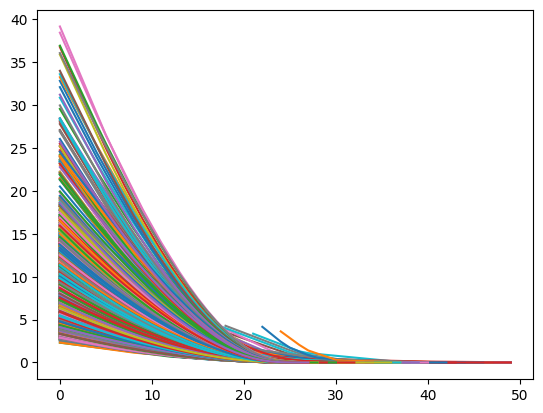

54it [00:00, 2843.27it/s]


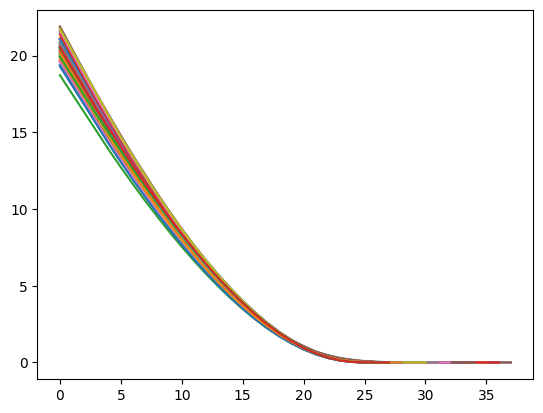

28it [00:00, 1749.37it/s]


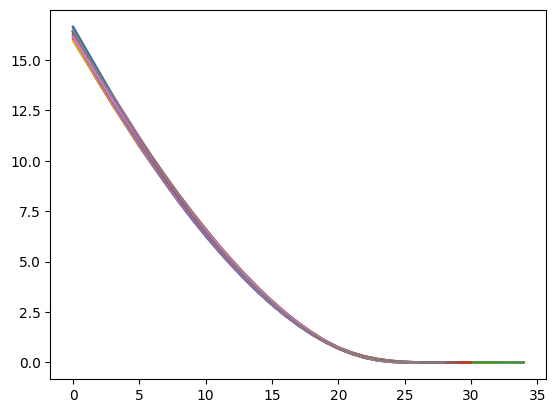

55it [00:00, 3094.26it/s]


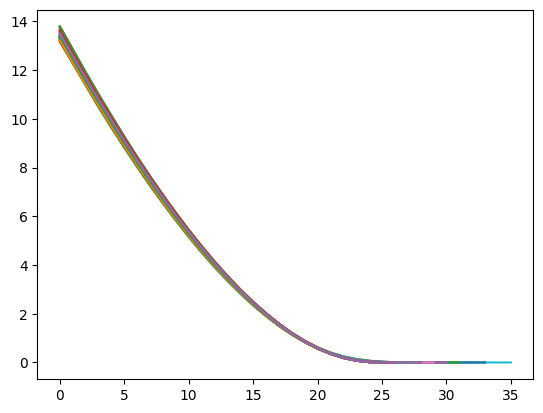

23it [00:00, 2125.15it/s]


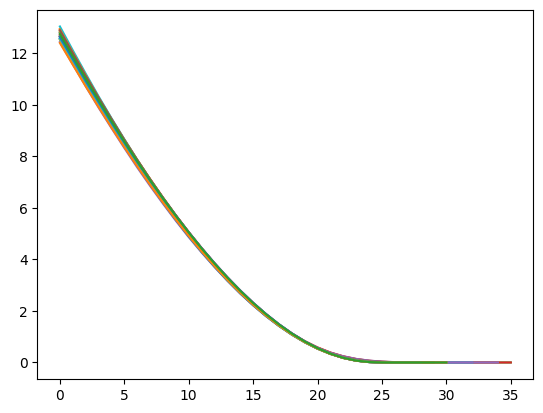

69it [00:00, 2539.48it/s]


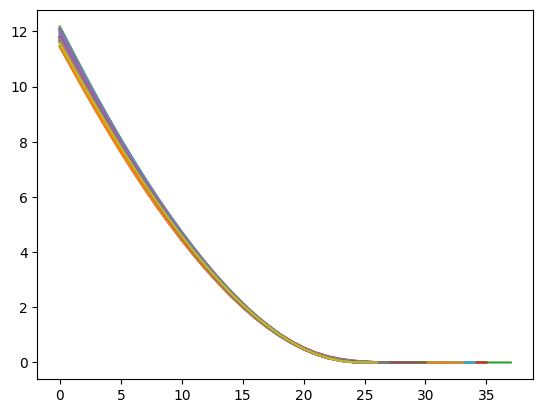

245it [00:00, 3823.25it/s]


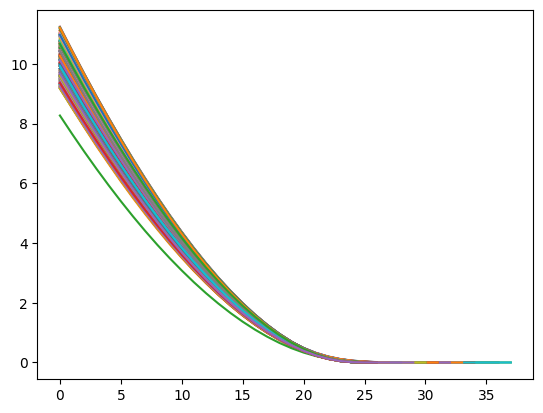

34it [00:00, 1284.66it/s]


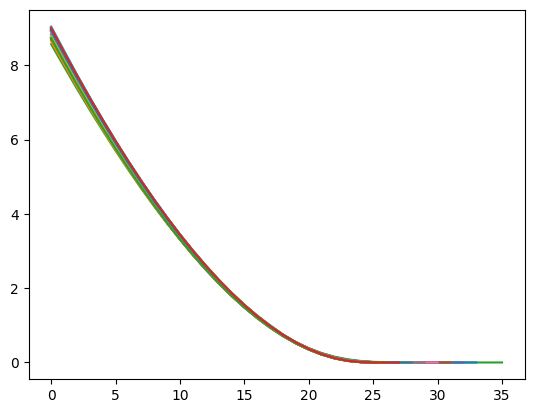

125it [00:00, 3384.05it/s]


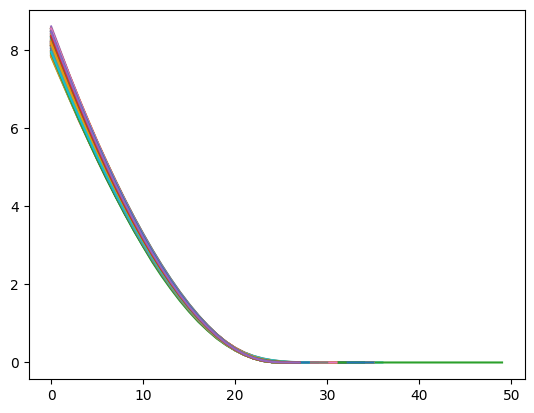

80it [00:00, 2991.79it/s]


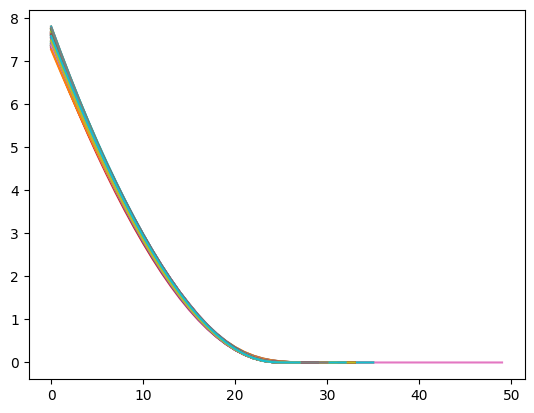

106it [00:00, 251.81it/s]


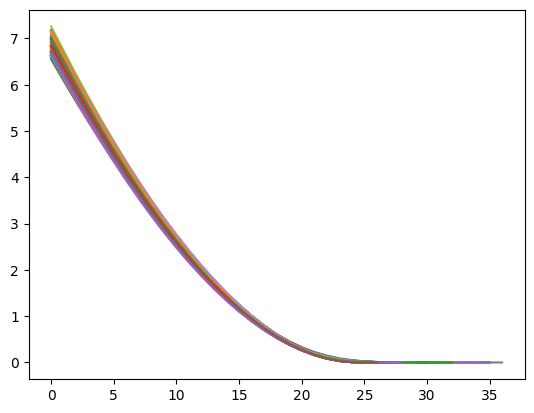

69it [00:00, 3272.02it/s]


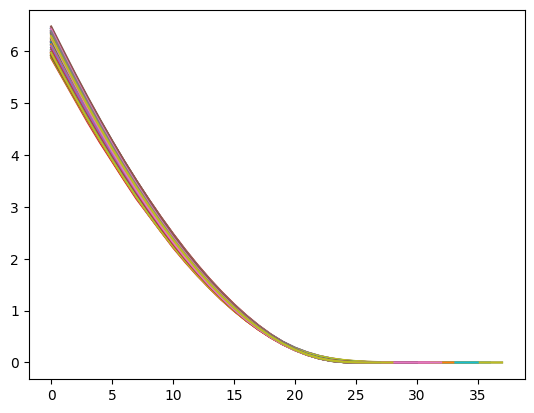

78it [00:00, 2388.33it/s]


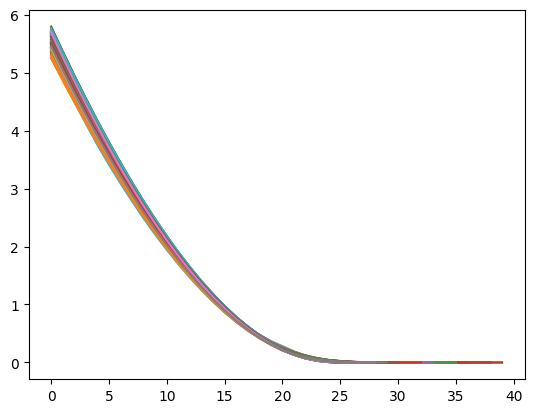

1976it [00:00, 4328.31it/s]


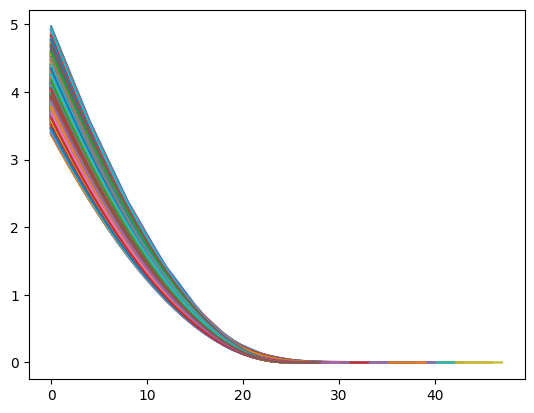

21it [00:00, 1851.83it/s]


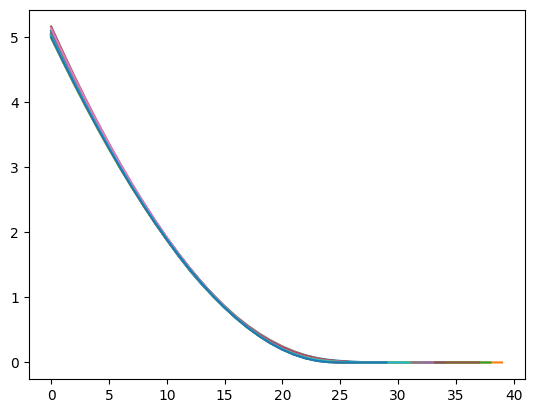

In [41]:
from tqdm import tqdm

N_SAMPLES_PER_CLUSTER = 4
colors = ["b", "r", "g", "black", "cyan"]

for groupID, (groupLabel, group) in enumerate(df.groupby("Group")):
    keys = np.load(datapath / f"group_{groupID}_keys.npy", allow_pickle=True)
    labels = np.load(datapath / f"group_{groupID}_hdbscan_labels.npy")
    medoids = np.load(datapath / f"group_{groupID}_kmedoid_medoids.npy")
    sliceMatrix = np.load(datapath / f"group_{groupID}_slices.npy")

    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    for cluster in clusters:
        sampleIdxs, = np.where(labels==cluster)
        # sampleIdxs = np.random.choice(idxs, N_SAMPLES_PER_CLUSTER, replace=False)

        for i, idx in tqdm(enumerate(sampleIdxs)):
            plt.plot(sliceMatrix[idx])
            # plt.plot(sliceMatrix[idx], color=colors[i], label=f"cluster_{i}")

        plt.show()
    break
